# **What is Micrograd?**

Micrograd is a lightweight, scalar-valued Automatic Differentiation (Autograd) engine and neural network library built from scratch in pure Python.

* **Core Engine:** It tracks dynamic scalar operations using a `Value` wrapper to build a **Directed Acyclic Graph (DAG)** of mathematical computations on the fly.
* **Key Functionality:** It implements **reverse-mode automatic differentiation (backpropagation)** to compute the gradient of every parameter with respect to a single scalar target node (the Loss).
* **Purpose:** It serves as a minimal, explicit implementation of the foundational mechanics powering modern deep learning frameworks like PyTorch and TensorFlow.

# **Calculus**


In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
# displays plots in the notebook
%matplotlib inline 

In [5]:
def f(x):
    return 3*x**2 - 4*x +5

In [6]:
f(3.0)

20.0

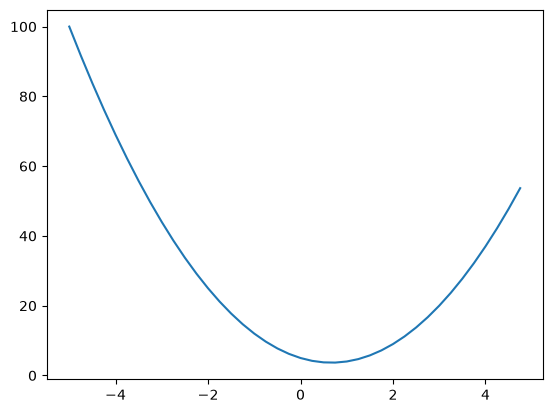

In [7]:
# creates 1D NumPy array: start at -5, end at 5, with a step of 0.25
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [11]:
h = 0.00000001
x = 2/3
(f(x + h) - f(x)) / h

0.0

In [ ]:
# more complex
# inputs
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

In [12]:
h = 0.0001
# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1) / h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


# **Value Object**
If it needs a gradient or participates in backpropagation, it must be a Value object

In [ ]:
# Wraps single number, tracks data
from platform import node


class Value: 
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        # short for previous-nodes
        self.l_backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    # to print out nicer-looking expression
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        #  Value(7, (a, b)) -- a & b are the parent nodes
        # Keep track of relations to trace back & see how input numbers affect outputs
        # the moment this is called, Python enters __init__ again for new node
        out = Value(self.data + other.data, (self, other), '+')

        # Backward Function: Automates backpropagation for addition
        def _backward():
            self.grad += out.grad * 1.0
            other.grad += out.grad * 1.0
        out._backward = _backward

        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')

        # Backward Function: Automates backpropagation for multiplication
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    # double underscores allow Python to plug custom class and methods into built-in operations
    # single underscores indicates internal attributes, not something a user needs to interact with

    def tanh(self):
        # Extracts raw data from Value object
        x = self.data
        # Math functions works on raw data, not Value objects
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        # Creates a new Value object with the result
        # Passes self in a tuple as child node (_prev) so backprop knows where to flow backwards
        out = Value(t, (self,), 'tanh')

        # Backward Function: Automates backpropagation for tanh
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out
    
    def backward(self):
    
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
            for child in v._prev:
                build_topo(child)
            # Append to topo after children
            # So that when we go through topo in reverse order, we go from outputs to inputs
            topo.append(v)
        build_topo(self)
    
        self.grad = 1.0
        for node in reversed(topo): # Flips the order of topo so we go from outputs to inputs
            # B/c the loop processses nodes in reverse order
            # We can be sure that when we call node._backward(), all the gradients of the nodes that depend on it have already been computed
            node._backward()

    

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label = 'c')
e = a * b; e.label='e'
d = e + c; d.label = 'd'
f = Value(2.0, label='f')
L = d * f; L.label='L'
d
# (a.__mul__(b).__add__(c))

Value(data=4.0)

In [14]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

# **Backpropagation**

In [ ]:
def lol():
    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label = 'c')
    e = a * b; e.label='e'
    d = e + c; d.label = 'd'
    f = Value(2.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data

    # Nudging variable 'a' by tiny amount (h) --> L change by ~6 times that amount
    a  = Value(2.0 + h, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label = 'c')
    e = a * b; e.label='e'
    d = e + c; d.label = 'd'
    f = Value(2.0, label='f')
    L = d * f; L.label='L'
    L2 = L.data

    print((L2 - L1) / h)

lol()

# DON'T RUN
# Output: 6.0000.... (this is how sensistive L is to a, i.e. dL/da = 6)

### **How Does Knowing the Sensitivity Help in ML**
Ultimate Goal of Training a Neural Network: Find optimal set of weights (parameters: coefficients) that minimizes the loss (error when making predictions).

Backpropagation is done after inputs are passed initially (forward pass) and the predictions and losses are computed. Then backpropagation computes the gradients.


### **Gradients**
Gradients show how sensitive the final output is to certain variables (inputs). Knowing each input's sensitivity allows us to know which ones are causing the inaccurate predictions and which needs to be fixed. The farther the sensitivity is from zero, the more disruption it's causing for the prediction leading to inaccuracy.

The high sensitivity is indicating that the weight is currently far away from its ideal spot.

** The input (x) cannot be physically changed but the weights accompanying it can be adjusted.

In [ ]:
# finding the gradient of the first step back from L
L = d * f

# dL/dd = f
# When two variables are multipled to get a PRODUCT, the gradient of the PRODUCT with respect to one of the variables is the other variable
# In this case, dL/dd = f. This means that if we want to find how sensitive L is to changes in d, we can look at the value of f.
# dL/df = d

# FOR ADDITION (d = c + e):
# The local gradient is 1. The addition gate just passes d's gradient straight through to both c and e.
# dL/dc = dL/dd * 1 = dL/dd

# DON'T RUN

#### **Finding Output's Sensitivity to an Input When There's Another Input Inbetween**
$$\frac{dL}{dc} = \frac{dL}{dd} \cdot \frac{dd}{dc}$$


### **Multiplication Swap Rule and Chain Rule**
Using the Chain Rule along the path $a, b \rightarrow e \rightarrow d \rightarrow L$:

$$\frac{\partial L}{\partial a} = \frac{\partial L}{\partial d} \cdot \frac{\partial d}{\partial e} \cdot \frac{\partial e}{\partial a} = (f) \cdot (1) \cdot (b) = f \cdot b$$

$$\frac{\partial L}{\partial b} = \frac{\partial L}{\partial d} \cdot \frac{\partial d}{\partial e} \cdot \frac{\partial e}{\partial b} = (f) \cdot (1) \cdot (a) = f \cdot a$$

**Substituting values ($f = -2.0$, $a = 2.0$, $b = -3.0$):**
* $\frac{\partial L}{\partial a} = (-2.0) \cdot (-3.0) = 6.0$
* $\frac{\partial L}{\partial b} = (-2.0) \cdot (2.0) = -4.0$

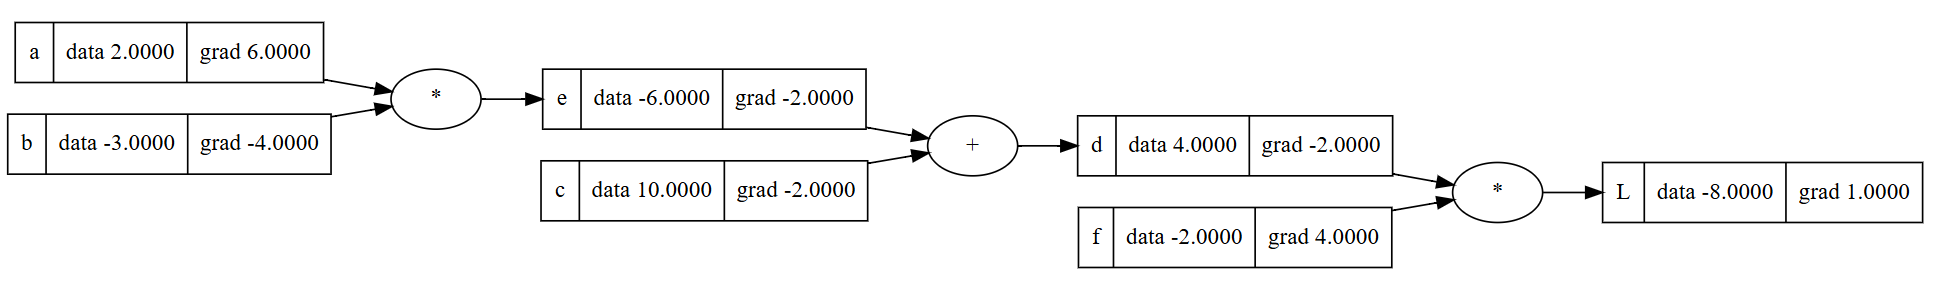

### **Gradient Descent vs. Gradient Ascent**
**Descent:** Minimization | Reduces Error, Loss, or Risk

**Ascent:** Maximization | Maximizes Reward, Probability, or Realism

In [ ]:
# Ascent
a.data += 0.01 * a.grad
# Descent
b.data -= 0.01 * b.grad

# **Backpropagation: Neuron**
A neuron acts as a feature detector and pattern matcher:
- Neuron takes in input
- Evalutes match to internal weights (those that get adjusted after backpropagation)
- Decides with activation function on how strongly to send a signal to the next neural layer

In [ ]:
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.881318, label='b')
# x1w1 + x2w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'

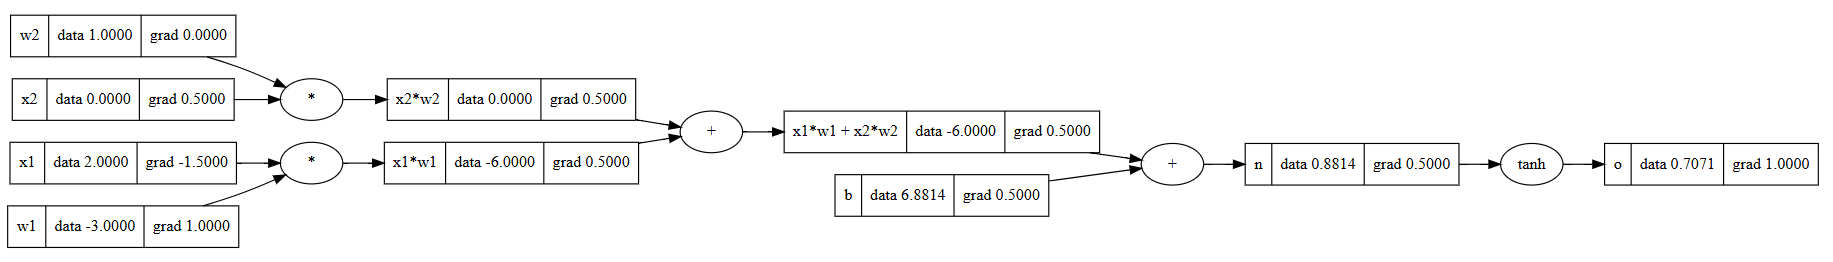

### **Signals**
A large signal can be good or bad depending on which layer it is occuring at.

Starting to Middle Layers: A high signal pushes the gradient near zero, which freezes learning and vanishes the gradient

Middle to Deep Layers: If activations grow without bound, signals and gradients can explode

Output/Final Layer: A high signal is only good if target is 1, not 0. We want to match the signal to the target, not just be high

# **Backward Function for Each Operation**

In [ ]:

# DON'T RUN -- ALL INSIDE VALUE OBJECT

# Backward Function: Automates backpropagation for addition
def _backward():
    self.grad += out.grad * 1.0
    other.grad += out.grad * 1.0
    out._backward = _backward

# Backward Function: Automates backpropagation for multiplication
def _backward():
    self.grad += other.data * out.grad
    other.grad += self.data * out.grad
    out._backward = _backward

# Backward Function: Automates backpropagation for tanh
def _backward():
    self.grad += (1 - t**2) * out.grad
out._backward = _backward

## **Topological Sorting**
Ensures that every node processes all of its outgoing dependencies before its own **backward()** function is executed

In [1]:
# DON'T RUN -- ALL INSIDE VALUE OBJECT
def backward(self):
    
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
            for child in v._prev:
                build_topo(child)
            # Append to topo after children
            # So that when we go through topo in reverse order, we go from outputs to inputs
            topo.append(v)
        build_topo(self)
    
        self.grad = 1.0
        for node in reversed(topo): # Flips the order of topo so we go from outputs to inputs
            # B/c the loop processses nodes in reverse order
            # We can be sure that when we call node._backward(), all the gradients of the nodes that depend on it have already been computed
            node._backward()

# **PyTorch Version**

In [ ]:
import torch

# Scales the same logic up to Tensors: n-dimensional arrays of numbers, instead of single numbers
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

# **Building Out a Neural Net Library | Multi-Layer Perceptron**

In [ ]:
class Neuron:

    def __init__(self, nin): # Takes n number of inputs
        self.w = [Value(np.random.randn()) for _ in range(nin)] # Creates a weight for each input, initialized randomly (-1 to 1)
        self.b = Value(random.uniform(-1, 1)) # Creates a bias term, initialized randomly (-1 to 1)

    def __call__(self, x):
        # pairs up matching weights and inputs, multiplies them, sums them, and adds the bias term
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b) # uses self.b as starting value instead of sum
        out = act.tanh() # passes total sum through tanh activation function
        return out # returns Value object that contains the output of the neuron

class Layer:

    def __init__(self, nin, nout):
        # Creates a list of neurons for the layer
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        # Calls each neuron in the layer with the input x and returns a list of outputs
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs # returns single output if only one neuron, otherwise returns list of outputs

class MLP:

    def __init__(self, nin, nouts):
        # Creates a list of layers for the MLP
        sz = [nin] + nouts # combines number of inputs and number of outputs for each layer
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))] # creates a layer for each pair of sizes

    def __call__(self, x):
        # Calls each layer in the MLP with the input x and returns the final output
        for layer in self.layers:
            x = layer(x)
        return x

x = [2.0, 3.0, -1.0]
# Layer 0: 3 inputs, 4 neurons | Layer 1: 4 inputs, 4 neurons | Layer 2: 4 inputs, 1 neuron
n = MLP(3, [4, 4, 1]) # Initiates an MLP with 3 inputs and 3 layers with 4, 4, and 1 outputs respectively
# n = Layer(2, 3) # Initiates a layer with 2 inputs and 3 neurons, which creates 3 sets of weights and bias terms
# n = Neuron(2) # Initiates a neuron with 2 inputs, which creates 2 weights and 1 bias term
n(x) # Triggers the __call__ method, which calculates the output of the neuron based on the inputs and weights

# **Gradient Descent**
$$w \leftarrow w - \eta \frac{\partial L}{\partial w}$$

**Parameter Nudging:** Gradient vector points in steepest ascent but the goal is to minimize loss so steps are taken in the opposite direction of the gradient.

**Too Large Steps:** Overshoots past minimal loss value

**Too Small Steps:** Long wait time till minimal value is reached (slow learning rate)

**Learning Rate:** Sets the scale/size of the steps taken to the minimal value